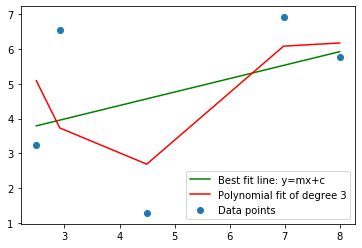

Linear least sqaures
MSE: 3.9740
R-squared: 0.1526

Polynomial Fit (Degree 3)
MSE: 2.8455
R-squared: 0.3932

The polynomial fit (degree 3) is the better fit


In [14]:
#Challenge A
import numpy as np
import matplotlib.pyplot as plt
x = np.sort(np.random.uniform(1, 10, 5))
y = np.random.uniform(1, 10, 5)
A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]

degree = 3
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

plt.scatter(x, y, label='Data points')
plt.plot(x, m*x + c, '-g', label='Best fit line: y=mx+c')
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.legend()
plt.show()

def evaluate_fit(y, y_pred, label):
    mse = np.mean((y - y_pred)**2)
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    print(label)
    print(f"MSE: {mse:.4f}")
    print(f"R-squared: {r_squared:.4f}\n")
    return mse, r_squared
mse_linear, r2_linear = evaluate_fit(y, m*x + c, "Linear least sqaures")
mse_poly, r2_poly = evaluate_fit(y, y_pred, f"Polynomial Fit (Degree {degree})")

if (mse_poly < mse_linear):
    print(f"The polynomial fit (degree {degree}) is the better fit")
else:
    print("The linear least squares is the better fit")

Degree 3: MSE =  2.8455, | R2 =  0.3932
Degree 4: MSE =  0.0000, | R2 =  1.0000
Degree 2: MSE =  3.3005, | R2 =  0.2962
Degree 1: MSE =  3.9740, | R2 =  0.1526


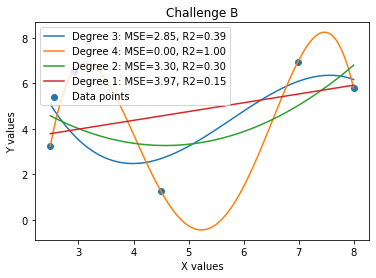

In [21]:
test_degrees = [3, 4, 2, 1]
x_smooth = np.linspace(x.min(), x.max(), 100)
plt.scatter(x, y, label='Data points')

for d in test_degrees:
    coeffs = np.polyfit(x, y, d)
    poly = np.poly1d(coeffs)
    y_pred = poly(x)
    
    mse = np.mean((y - y_pred)**2)
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    
    label_text = f'Degree {d}: MSE={mse:.2f}, R2={r_squared:.2f}'
    plt.plot(x_smooth, poly(x_smooth), label=label_text)
    
    print(f"Degree {d}: MSE = {mse:7.4f}, | R2 = {r_squared:7.4f}")
    
plt.title("Challenge B")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.legend()
plt.show()

Manual coefficients: [ 27.71502381 -15.36392081   2.94298347  -0.16988808]
Manual MSE: 2.8455
Manual R2: 0.3932


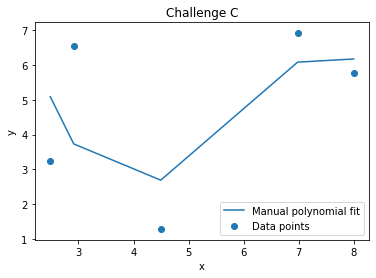

In [23]:
#challenge 3
degree = 3
V = np.vander(x, N=degree + 1, increasing=True)
VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, y)
coeffs = np.linalg.solve(VT_V, VT_y)
y_pred = np.dot(V, coeffs)

mse = np.mean((y - y_pred)**2)
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f"Manual coefficients: {coeffs}")
print(f"Manual MSE: {mse:.4f}")
print(f"Manual R2: {r_squared:.4f}")

plt.scatter(x, y, label='Data points')
plt.plot(x, y_pred, label='Manual polynomial fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Challenge C')
plt.legend()
plt.show()